# FoodNet — Supervised vs Self-Supervised Learning

This notebook trains a **custom CNN (< 10 M parameters, no pretrained weights)** to classify the
Food-251 dataset (251 classes, 100–600 images/class, uncontrolled input size), and solves the task under
**two paradigms** required by the specification:

1. **Supervised Learning (SL)** — the custom CNN is trained end-to-end with labels.
2. **Self-Supervised Learning (SSL)** — the *same* backbone is pretrained on the images **ignoring the labels**
   (SimCLR contrastive / rotation pretext), then its frozen features are classified with a **traditional classifier**
   (logistic regression / linear SVM / kNN).

Because the official test set has no public ground truth, the **validation set is our test set** and is
**stratified-split out of the training data** so all 251 classes are represented.


## 1. Setup — paths, seed, device

In [ ]:
import sys, os
from pathlib import Path
import warnings; warnings.filterwarnings("ignore")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

# Make `codes` importable when running from notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from codes import config as C
from codes import utils as U
from codes import data_handler as dh
from codes import model as M
from codes import loss_function as L
from codes import train as T
from codes import evaluate as E
from codes import self_supervised as S
from codes import hyperparameter_tuning as HT

U.set_seed(C.SEED)
device = U.get_device()
U.create_directories(C.MODELS_DIR, C.RESULTS_DIR)
print("Device:", device)

## 2. Load dataset manifest
Load the labels CSV and normalise it to `image_id` / `label`. We defer the train/validation split until **after**
outlier handling, so the split is built from the cleaned manifest.

In [ ]:
train_df = dh.build_dataframe(C.TRAIN_CSV)
test_df = dh.build_dataframe(C.TEST_CSV)
print(f"Loaded {len(train_df):,} training images across {train_df['label'].nunique()} classes")
print(f"Loaded {len(test_df):,} test images across {test_df['label'].nunique()} classes")
assert train_df['label'].nunique() == C.NUM_CLASSES, "Dataset must keep all 251 classes"
assert test_df['label'].nunique() == C.NUM_CLASSES, "Dataset must keep all 251 classes"
class_names = dh.load_class_names(train_df, C.NUM_CLASSES)

Loaded 118,475 training images across 251 classes
Loaded 11,994 test images across 251 classes


Total images  : 118,475
Unique classes: 251

Smallest 5 classes:
label
103    300
83     290
164    289
213    277
162     34
Name: count, dtype: int64

Largest 5 classes:
label
218    656
147    636
155    635
0      633
117    617
Name: count, dtype: int64


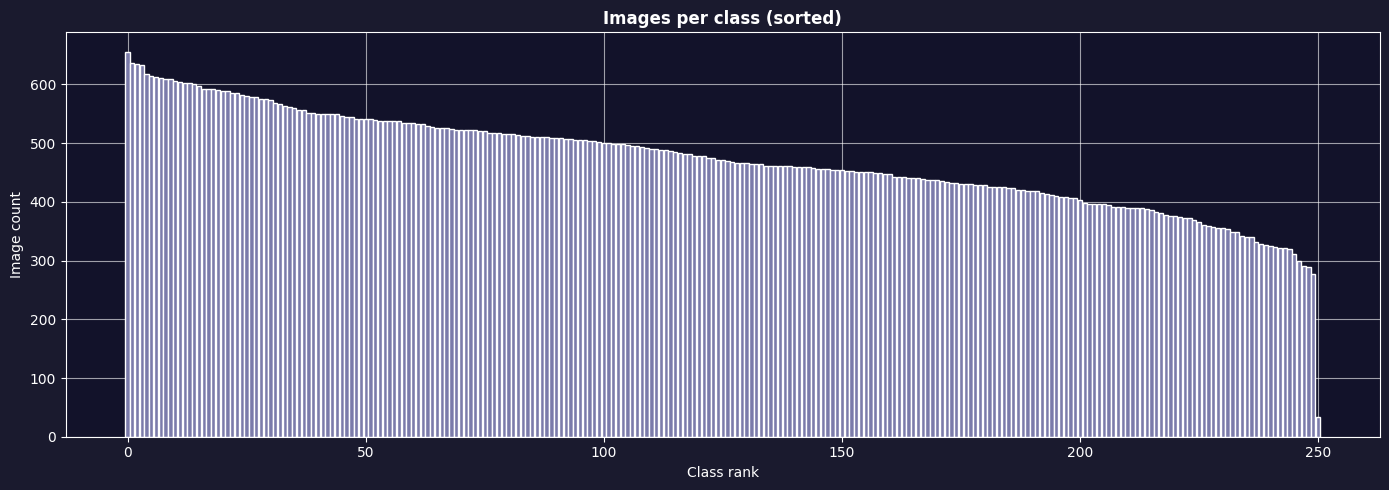

↑ saved class_distribution.png


In [ ]:
# Class distribution
label_col = [c for c in train_df.columns if c.lower() in
             ("label","class","class_id","category","target")][0]
class_counts = train_df[label_col].value_counts()

print(f"Total images  : {len(train_df):,}")
print(f"Unique classes: {train_df[label_col].nunique()}")
print(f"\nSmallest 5 classes:\n{class_counts.tail()}")
print(f"\nLargest 5 classes:\n{class_counts.head()}")

counts = sorted(class_counts.values, reverse=True)

fig, ax = plt.subplots(figsize=(14, 5), facecolor="#1a1a2e")
ax.set_facecolor("#12122a")

ax.bar(range(len(counts)), counts, color="#7b7baa", edgecolor="white", linewidth=1.0, width=0.9 )

ax.set_xlabel("Class rank", color="white")
ax.set_ylabel("Image count", color="white")
ax.set_title( "Images per class (sorted)",color="white",fontweight="bold")

ax.tick_params(colors="white")

# grid like second plot
ax.grid(True,color="white",alpha=0.6,linestyle="-")

ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_color("white")

plt.tight_layout()

plt.savefig(os.path.join(C.RESULTS_DIR, "class_distribution.png"),
            dpi=120, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("↑ saved class_distribution.png")

## 3. Outlier handling (3-stage pipeline)
A compact, food-aware version of the AgroVision 3-stage audit, run inline:

1. **Stage 1 — integrity** (auto-removed): missing / corrupt / undersized / near-black / near-white / low-contrast.
2. **Stage 2 — pixel statistics** (flagged for review): colour / texture / uniqueness bounds catch likely non-food images.
3. **Stage 3 — embeddings** (flagged for review): ResNet-50 features + global & per-class IsolationForest catch images
   that look unlike their own class (mislabels, off-topic shots).

Stages 2–3 only *flag* — after a quick visual review you confirm removals and write a cleaned manifest, which the
rest of the notebook then trains on. Set `SKIP_STAGE3 = True` for a fast CPU-only first pass.

In [ ]:
from codes.outlier_handler import (
    run_outlier_pipeline, visualize_flagged_images,
    plot_anomaly_score_distribution, apply_review_decisions,
    N_FAILS_DEFAULT,
)

PER_CLASS_THR = -0.15   # lower → more Stage-3 flags
GLOBAL_THR    = -0.12
SKIP_STAGE3   = False    # set True for a quick CPU-only first pass

(
    df_clean,         # Stage-1 cleaned manifest (integrity failures removed)
    stats_df,         # Stage-2 pixel statistics (all images)
    flagged2,         # Stage-2 flagged (review)
    feats,            # Stage-3 PCA embeddings
    emb_ids,          # Stage-3 image IDs
    global_scores,    # Stage-3 global IF scores
    per_class_scores, # Stage-3 per-class IF scores
    flagged3,         # Stage-3 flagged (review)
) = run_outlier_pipeline(
    csv_path      = str(C.TRAIN_CSV),
    img_dir       = str(C.IMAGE_DIR),
    out_dir       = str(C.RESULTS_DIR),
    device        = str(device),
    global_thr    = GLOBAL_THR,
    per_class_thr = PER_CLASS_THR,
    n_fails_required = N_FAILS_DEFAULT,
    skip_stage3   = SKIP_STAGE3,
)

In [ ]:
# Stage 1 — integrity (auto-removed, no review needed)
s1_log = C.RESULTS_DIR / 'removed_stage1_integrity.csv'
if s1_log.exists():
    s1_df = pd.read_csv(s1_log)
    print(f'Auto-removed: {len(s1_df):,}')
    display(s1_df['reason'].str.split('(').str[0].value_counts().to_frame('count'))
else:
    print('All images passed Stage 1 ✓')
print(f'Surviving after Stage 1: {len(df_clean):,}  |  classes: {df_clean["label"].nunique()}')

Auto-removed: 22


,count
reason,
near_black,16
near_white_blank,5
low_contrast,1


Surviving after Stage 1: 118,453  |  classes: 251


In [ ]:
# Stage 2 — review flagged (likely non-food by pixel statistics)
print(f'Stage 2 flagged: {len(flagged2):,} / {len(stats_df):,}')
if not flagged2.empty:
    cols = [c for c in ['image_id','label','n_fails','fail_reasons'] if c in flagged2.columns]
    display(flagged2[cols].head(20))
    visualize_flagged_images(flagged2, str(C.IMAGE_DIR), title='Stage 2 — non-food (pixel stats)',
                             save_path=str(C.RESULTS_DIR / 'stage2_flagged_grid.png'))

Stage 2 flagged: 638 / 118,453


,image_id,label,n_fails,fail_reasons
0,train_100935.jpg,174,3,"saturation_mean=0.000[4.0,248.0]; grey_fractio..."
1,train_087410.jpg,99,3,"saturation_mean=0.000[4.0,248.0]; grey_fractio..."
2,train_029038.jpg,87,3,"saturation_mean=0.000[4.0,248.0]; grey_fractio..."
3,train_082071.jpg,65,3,"saturation_mean=0.758[4.0,248.0]; grey_fractio..."
4,train_082172.jpg,65,3,"saturation_mean=0.000[4.0,248.0]; grey_fractio..."
5,train_082254.jpg,65,3,"saturation_mean=0.000[4.0,248.0]; grey_fractio..."
6,train_025310.jpg,171,3,"saturation_mean=0.701[4.0,248.0]; grey_fractio..."
7,train_082340.jpg,65,3,"saturation_mean=0.000[4.0,248.0]; grey_fractio..."
8,train_082372.jpg,65,3,"saturation_mean=1.069[4.0,248.0]; grey_fractio..."
9,train_082386.jpg,65,3,"saturation_mean=0.000[4.0,248.0]; grey_fractio..."


  -> saved grid: /Users/mulatyazewchekol/Documents/My_Projects/Final_Projects/Image-classification-Supervised-vs-Self-Supervised-Learning/results/stage2_flagged_grid.png


In [ ]:
# Stage 3 — review embedding outliers
if not SKIP_STAGE3 and len(per_class_scores) > 0:
    print(f'Stage 3 flagged: {len(flagged3):,}')
    plot_anomaly_score_distribution(per_class_scores, score_thr=PER_CLASS_THR,
        title='Stage 3 — per-class IsolationForest scores',
        save_path=str(C.RESULTS_DIR / 'stage3_anomaly_dist.png'))
    if not flagged3.empty:
        visualize_flagged_images(flagged3, str(C.IMAGE_DIR), title='Stage 3 — embedding outliers',
                                 save_path=str(C.RESULTS_DIR / 'stage3_flagged_grid.png'))
else:
    print('Stage 3 skipped.')

Stage 3 flagged: 148
  -> saved grid: /Users/mulatyazewchekol/Documents/My_Projects/Final_Projects/Image-classification-Supervised-vs-Self-Supervised-Learning/results/stage3_flagged_grid.png


In [ ]:
# ACTION: after visual review, confirm removals → cleaned manifest.
# The review CSVs (results/review_stage2_*.csv, review_stage3_*.csv) default every row to "remove";
# edit them to "keep" any false positives, save as confirmed_remove_stage{2,3}.csv, then:
confirmed = [p for p in (C.RESULTS_DIR/'confirmed_remove_stage2.csv',
                         C.RESULTS_DIR/'confirmed_remove_stage3.csv') if p.exists()]
if confirmed:
    df_final = apply_review_decisions(df_clean, [str(p) for p in confirmed],
                                      output_csv=str(C.CLEAN_CSV))
else:
    # No confirmed removals yet → proceed with the Stage-1 cleaned manifest.
    df_final = df_clean.copy()
    df_final.to_csv(C.CLEAN_CSV, index=False)
print(f'Training manifest: {len(df_final):,} images across {df_final["label"].nunique()} classes')
assert df_final['label'].nunique() == C.NUM_CLASSES, 'All 251 classes must survive cleaning'

In [ ]:
from codes.outlier_handler import audit_summary_report

# Per-class audit trail across all 3 stages: confirms the cleaning pipeline
# did not gut any class (especially the ~34-image tail classes) below a
# usable minimum. Written to results/outlier_summary_by_class.csv.
outlier_summary = audit_summary_report(
    raw_df=train_df, stage1_df=df_clean, flagged2_df=flagged2, flagged3_df=flagged3,
    final_df=df_final, num_classes=C.NUM_CLASSES, out_dir=str(C.RESULTS_DIR),
    min_remaining=C.OUTLIER_MIN_CLASS_REMAINING,
)


## 3b. Preprocessing — sub-sample & stratified split
Optionally cap images-per-class for documented computational reasons (the **number of classes stays 251**), then build
the **stratified** train/validation split from the cleaned manifest. Preprocessing per image (resize to a common
`INPUT_SIZE` square, keep RGB, ImageNet normalisation) is applied inside the dataset pipelines.

In [ ]:
# Cap images per class only (classes preserved) — a config-driven, documented
# computational-cost decision (config.MAX_IMAGES_PER_CLASS; None = full data).
# Reads the CLEANED manifest (post-outlier-removal), not the raw CSV.
df = pd.read_csv(C.CLEAN_CSV)

df = dh.cap_images_per_class(df, C.MAX_IMAGES_PER_CLASS, seed=C.SEED)
print(f"After sampling: {len(df):,} images across {df['label'].nunique()} classes "
      f"(cap={C.MAX_IMAGES_PER_CLASS or 'none -- full data'})")

# Validation = our test set, stratified out of train.
train_df, val_df = dh.stratified_split(df, val_split=C.VAL_SPLIT, seed=C.SEED)
print(f"Train: {len(train_df):,}  |  Val(=test): {len(val_df):,}")
print(f"Classes present in val: {val_df['label'].nunique()} / {C.NUM_CLASSES}")

# Class-distribution sanity plot
counts = train_df['label'].value_counts().sort_index()
plt.figure(figsize=(14,3))
plt.bar(counts.index, counts.values, width=1.0)
plt.title("Training images per class (251 classes)")
plt.xlabel("class id"); plt.ylabel("count"); plt.tight_layout(); plt.show()
print("min/median/max per class:", counts.min(), int(counts.median()), counts.max())


In [ ]:
# Tail classes: smallest TAIL_CLASS_FRACTION of classes by image count. Shared
# definition reused for (a) class-aware augmentation boost (next cell) and
# (b) head/tail per-class metric reporting later, so both stay consistent.
tail_classes = dh.compute_tail_classes(train_df, C.NUM_CLASSES, C.TAIL_CLASS_FRACTION)
print(f"{len(tail_classes)} tail classes (of {C.NUM_CLASSES}), "
      f"e.g. {sorted(list(tail_classes))[:10]}...")


## Output files reference
| File | Stage | Purpose |
|---|---|---|
| `removed_stage1_integrity.csv` | 1 | Auto-removed images (no review needed) |
| `review_stage2_nonfood_pixelstats.csv` | 2 | All flagged images to review |
| `review_stage3_nonfood_embedding.csv` | 3 | All embedding-flagged images to review |
| `train_labels_clean.csv` | Final | Cleaned manifest — use for training |
| `class_distribution.png` | EDA | Image count per class |
| `stage2_flagged_grid.png` | 2 | Thumbnail grid of flagged images |
| `stage3_perclass_score_dist.png` | 3 | Per-class IF score histogram |
| `stage3_flagged_grid.png` | 3 | Thumbnail grid of flagged images |

All files are written to `../results/`.


## 4. DataLoaders
Class imbalance is handled via weighted CE / focal loss (see `loss_function.py`). A single uniform
augmentation pipeline is applied across all classes. Pick ONE class-frequency correction:
weighted sampler XOR loss weights (here we use loss weights via `config.LOSS_TYPE`).

In [ ]:
# Datasets -- tail classes get a boosted augmentation intensity (class-aware
# augmentation, config.USE_TAIL_AWARE_AUGMENTATION); every other class uses
# the uniform config.AUGMENTATION_INTENSITY. Validation uses no augmentation
# (deterministic evaluation).
aug_tail_classes = tail_classes if C.USE_TAIL_AWARE_AUGMENTATION else None
train_ds = dh.FoodDataset(train_df, C.IMAGE_DIR, augment=True, image_size=C.INPUT_SIZE,
                          intensity=C.AUGMENTATION_INTENSITY,
                          tail_classes=aug_tail_classes, tail_boost=C.TAIL_AUG_BOOST)
val_ds   = dh.FoodDataset(val_df,   C.IMAGE_DIR, augment=False, image_size=C.INPUT_SIZE)
test_ds  = dh.FoodDataset(test_df,  C.IMAGE_DIR, augment=False, image_size=C.INPUT_SIZE)

# Pick ONE imbalance correction: weighted sampler OR loss weights (see config).
sampler = dh.build_weighted_sampler(train_df, C.NUM_CLASSES) if C.USE_WEIGHTED_SAMPLER else None
train_loader = DataLoader(train_ds, batch_size=C.BATCH_SIZE, shuffle=(sampler is None),
                          sampler=sampler, num_workers=C.NUM_WORKERS, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=C.BATCH_SIZE, shuffle=False,
                          num_workers=C.NUM_WORKERS)

print("Train images:", len(train_ds), "| Val images:", len(val_ds))


## 5. Custom CNN — architecture & parameter budget
Two architectures are available: **FoodNet30** (30 Conv2d layers, residual DWS + SE) and
**FoodNet46** (46 Conv2d layers, MBConv inverted-residual + SE + DropPath). Both are built
**from scratch** (no pretrained weights). The active model is set by `config.MODEL_ARCHITECTURE`.
We verify the **< 10 M parameter** constraint before training.

In [ ]:
model = M.build_model(C.MODEL_ARCHITECTURE, num_classes=C.NUM_CLASSES,
                      dropout=C.DROPOUT, width_mult=C.WIDTH_MULT)
info = model.model_info()
print(info)
assert info['under_10M'], "Model exceeds the 10M parameter budget!"
U.assert_param_budget(model)

{'name': 'foodnet_v2', 'total_params_M': 7.643, 'frozen_params_M': 0.0, 'trainable_params_M': 7.643, 'feature_dim': 960, 'under_10M': True}


7642811

## 6. Task A — Supervised Learning: tune, select, retrain

We tune the supervised model with a full grid (`default_sl_grid`). Each
configuration is probed for a few epochs and ranked by validation accuracy,
subject to the under-10M parameter budget. For every configuration we keep the
probe history so the loss and accuracy curves can be compared, and we save the
full results table to CSV. The winning configuration is then retrained to
convergence and its best checkpoint is saved.

### 6a. Hyperparameter search (Phase A/B -- cheap search, then confirm)
Search on a documented capped subset (`config.TUNE_SUBSET_IMAGES_PER_CLASS`),
ranked by validation **macro-F1** (not accuracy -- see `config.TUNE_SELECTION_METRIC`),
using `config.TUNE_STRATEGY` (successive halving by default). LR/weight-decay/
dropout are tuned first; the imbalance axis (loss type x class-weight scheme)
is then tuned as its own small grid holding that winner fixed. Phase C (next
section) retrains the winner on the FULL dataset for the full epoch budget --
the only run that goes the full distance.

Augmentation-intensity/mix-method and architecture-width axes are available
via `HT.augmentation_grid()` / `width_mult` but are not auto-wired into a
further phase here, to keep the notebook's default run tractable -- rerun the
same `grid_with_overrides(best_sl_cfg, HT.augmentation_grid())` pattern below
if you want to sweep them too.


In [ ]:
# Phase A: cheap search on a documented capped subset, successive halving
# over LR / optimizer / weight-decay / dropout, ranked by macro-F1.
tune_df = dh.cap_images_per_class(df_final, C.TUNE_SUBSET_IMAGES_PER_CLASS, seed=C.SEED)
tune_train_df, tune_val_df = dh.stratified_split(tune_df, val_split=C.VAL_SPLIT, seed=C.SEED)

tune_train_loader = DataLoader(
    dh.FoodDataset(tune_train_df, C.IMAGE_DIR, augment=True, image_size=C.INPUT_SIZE,
                  intensity=C.AUGMENTATION_INTENSITY),
    batch_size=C.BATCH_SIZE, shuffle=True, num_workers=C.NUM_WORKERS)
tune_val_loader = DataLoader(
    dh.FoodDataset(tune_val_df, C.IMAGE_DIR, augment=False, image_size=C.INPUT_SIZE),
    batch_size=C.BATCH_SIZE, num_workers=C.NUM_WORKERS)

sl_best, sl_results = HT.tune_supervised(
    tune_train_loader, tune_val_loader, device=device, grid=HT.default_sl_grid(),
    probe_epochs=C.TUNE_PROBE_EPOCHS, num_classes=C.NUM_CLASSES,
    strategy=C.TUNE_STRATEGY, selection_metric=C.TUNE_SELECTION_METRIC,
    n_random_configs=C.TUNE_N_RANDOM_CONFIGS, use_weighted_sampler=C.USE_WEIGHTED_SAMPLER,
    data_subset="capped", csv_path=str(C.RESULTS_DIR / "sl_tuning_lr_wd_dropout.csv"))

# Phase A continued: imbalance axis (loss_type x class_weight_scheme), its own
# small grid, holding the winning LR/WD/dropout/model config fixed.
imb_grid = HT.grid_with_overrides(sl_best.config, HT.imbalance_grid())
imb_best, imb_results = HT.tune_supervised(
    tune_train_loader, tune_val_loader, device=device, grid=imb_grid,
    probe_epochs=C.TUNE_PROBE_EPOCHS, num_classes=C.NUM_CLASSES, strategy="grid",
    selection_metric=C.TUNE_SELECTION_METRIC, use_weighted_sampler=C.USE_WEIGHTED_SAMPLER,
    data_subset="capped", csv_path=str(C.RESULTS_DIR / "sl_tuning_imbalance.csv"))

HT.write_tuning_summary(imb_best, sl_results + imb_results,
                        str(C.RESULTS_DIR / "sl_tuning_summary.md"), n=5,
                        selection_metric=C.TUNE_SELECTION_METRIC)
best_sl_cfg = imb_best.config
print("Winning SL config (Phase A/B):", best_sl_cfg)


In [ ]:
# Phase C: retrain the winning config on the FULL dataset for the full epoch
# budget (the only run that goes the full distance), with early stopping.
model = M.build_model(best_sl_cfg["model_name"], num_classes=C.NUM_CLASSES,
                      dropout=best_sl_cfg.get("dropout", C.DROPOUT),
                      width_mult=best_sl_cfg.get("width_mult", C.WIDTH_MULT))
U.assert_param_budget(model)
print(model.model_info())

# Loss with class-imbalance handling (winning scheme from Phase A/B, unless a
# weighted sampler is active -- then weights are skipped to avoid double-correcting).
class_weights = None if C.USE_WEIGHTED_SAMPLER else dh.compute_class_weights(
    train_df, C.NUM_CLASSES, scheme=best_sl_cfg.get("class_weight_scheme", C.CLASS_WEIGHT_SCHEME)).to(device)
dh.check_single_imbalance_correction(C.USE_WEIGHTED_SAMPLER, class_weights)
criterion = L.build_criterion(best_sl_cfg.get("loss_type", C.LOSS_TYPE), class_weights=class_weights,
                              gamma=C.FOCAL_GAMMA, label_smoothing=best_sl_cfg.get("label_smoothing", C.LABEL_SMOOTHING))

trainer = T.Trainer(model, device, criterion=criterion,
                    learning_rate=best_sl_cfg.get("lr", C.LEARNING_RATE),
                    weight_decay=best_sl_cfg.get("weight_decay", C.WEIGHT_DECAY),
                    mix_method=C.MIX_METHOD, mixup_alpha=C.MIXUP_ALPHA, cutmix_alpha=C.CUTMIX_ALPHA)
sl_history = trainer.train(train_loader, val_loader,
                           num_epochs=C.NUM_EPOCHS, patience=C.PATIENCE,
                           model_save_dir=str(C.MODELS_DIR), run_name="supervised",
                           log_per_class_every=C.LOG_PER_CLASS_EVERY,
                           class_names=list(class_names.values()), tail_classes=tail_classes,
                           results_dir=str(C.RESULTS_DIR))


In [ ]:
E.plot_training_curves(sl_history, save_path=str(C.RESULTS_DIR / "sl_curves.png"))

# Load the best checkpoint and evaluate on the test split.
trainer.load_checkpoint(C.MODELS_DIR / "supervised" / "best_model.pth", weights_only=True)
evaluator = E.Evaluator(num_classes=C.NUM_CLASSES,
                        class_names=list(class_names.values()), device=device)
sl_result = evaluator.evaluate(model, val_loader)
print("Supervised metrics:")
for k, v in sl_result["metrics"].items():
    print(f"  {k:20s}: {v:.4f}")
print("Top-5 accuracy:", round(E.Evaluator.top_k_accuracy(model, val_loader, device, k=5), 4))

# Per-class report + head/tail breakdown -- confirms the tail (~34-image)
# classes are actually improving, not just the head classes inflating macro-F1.
sl_per_class = evaluator.per_class_metrics(sl_result["true_labels"], sl_result["predictions"])
sl_per_class.to_csv(C.RESULTS_DIR / "sl_per_class_final.csv", index=False)
sl_tail_head = evaluator.head_vs_tail_summary(sl_per_class, tail_classes=tail_classes)
print("SL tail vs head:", sl_tail_head)

T.log_run("supervised_final", best_sl_cfg,
         {**sl_result["metrics"], **sl_tail_head}, str(C.RESULTS_DIR / "experiment_log.csv"))


In [ ]:
evaluator.plot_confusion_matrix(sl_result['true_labels'], sl_result['predictions'],
                                normalize=True, save_path=str(C.RESULTS_DIR/"sl_confusion.png"))

## 7. Task B — Self-Supervised Learning: tune each method, then compare

The SSL paradigm pretrains the same backbone without labels, freezes it,
extracts features, and classifies them with a traditional classifier. We tune
the two pretext methods separately, because they consume different inputs:
SimCLR needs augmented image pairs, rotation needs single images. Each method is
tuned with a full grid (learning rate, temperature for SimCLR, downstream
classifier, width). The best configuration of each is retrained to convergence,
and the two are compared so the better pretext method is selected.

In [ ]:
# Loaders for SSL. SimCLR consumes augmented pairs; rotation and feature
# extraction consume single images.
ssl_pair_loader = DataLoader(
    dh.SSLPairDataset(train_df, C.IMAGE_DIR, image_size=C.INPUT_SIZE),
    batch_size=C.SSL_BATCH_SIZE, shuffle=True, num_workers=C.NUM_WORKERS, drop_last=True)

ssl_image_loader = DataLoader(
    dh.FeatureExtractionDataset(train_df, C.IMAGE_DIR, image_size=C.INPUT_SIZE),
    batch_size=C.SSL_BATCH_SIZE, shuffle=True, num_workers=C.NUM_WORKERS, drop_last=True)

feat_train_loader = DataLoader(
    dh.FeatureExtractionDataset(train_df, C.IMAGE_DIR, image_size=C.INPUT_SIZE),
    batch_size=C.BATCH_SIZE, num_workers=C.NUM_WORKERS)
feat_val_loader = DataLoader(
    dh.FeatureExtractionDataset(val_df, C.IMAGE_DIR, image_size=C.INPUT_SIZE),
    batch_size=C.BATCH_SIZE, num_workers=C.NUM_WORKERS)

In [ ]:
# Tune SimCLR and rotation separately with full grids.
ssl_grid = HT.default_ssl_grid()

simclr_best, simclr_results = HT.tune_ssl(
    ssl_pair_loader, feat_train_loader, feat_val_loader,
    method="simclr", device=device, grid=ssl_grid,
    probe_epochs=C.SSL_TUNE_PROBE_EPOCHS, num_classes=C.NUM_CLASSES,
    csv_path=str(C.RESULTS_DIR / "ssl_simclr_tuning.csv"))

rotation_best, rotation_results = HT.tune_ssl(
    ssl_image_loader, feat_train_loader, feat_val_loader,
    method="rotation", device=device, grid=ssl_grid,
    probe_epochs=C.SSL_TUNE_PROBE_EPOCHS, num_classes=C.NUM_CLASSES,
    csv_path=str(C.RESULTS_DIR / "ssl_rotation_tuning.csv"))

ssl_choice = HT.compare_ssl_methods(simclr_best, rotation_best)
print("Selected SSL method:", ssl_choice["winner"])

In [ ]:
# Retrain the winning SSL method at its best config to convergence,
# then read out features with the tuned classifier.
winner = ssl_choice["winner"]
best_ssl_cfg = (simclr_best if winner == "simclr" else rotation_best).config
ssl_loader = ssl_pair_loader if winner == "simclr" else ssl_image_loader

ssl_backbone = M.build_model(best_ssl_cfg["model_name"], num_classes=C.NUM_CLASSES,
                             width_mult=best_ssl_cfg.get("width_mult", C.WIDTH_MULT))

ssl_out = S.run_ssl_pipeline(
    ssl_backbone, ssl_loader, feat_train_loader, feat_val_loader, device,
    method=winner, classifier=best_ssl_cfg.get("classifier", C.SSL_CLASSIFIER),
    epochs=C.SSL_EPOCHS, lr=best_ssl_cfg.get("lr", C.SSL_LEARNING_RATE),
    weight_decay=best_ssl_cfg.get("weight_decay", C.SSL_WEIGHT_DECAY),
    temperature=best_ssl_cfg.get("temperature", C.SSL_TEMPERATURE),
    projection_dim=best_ssl_cfg.get("projection_dim", C.SSL_PROJECTION_DIM),
    save_path=str(C.MODELS_DIR / "ssl_best" / "backbone.pth"))

In [ ]:
ssl_metrics = E.Evaluator.metrics_from_predictions(
    ssl_out["val_labels"], ssl_out["val_predictions"])
print(f"SSL ({winner}) metrics:")
for k, v in ssl_metrics.items():
    print(f"  {k:20s}: {v:.4f}")

In [ ]:
# Per-class report + head/tail breakdown for SSL, using the SAME Evaluator /
# tail_classes definition as the SL branch above, for a fair SL-vs-SSL comparison.
ssl_per_class = evaluator.per_class_metrics(ssl_out["val_labels"], ssl_out["val_predictions"])
ssl_per_class.to_csv(C.RESULTS_DIR / "ssl_per_class_final.csv", index=False)
ssl_tail_head = evaluator.head_vs_tail_summary(ssl_per_class, tail_classes=tail_classes)
print("SSL tail vs head:", ssl_tail_head)

T.log_run(f"ssl_{winner}_final", best_ssl_cfg,
         {**ssl_metrics, **ssl_tail_head}, str(C.RESULTS_DIR / "experiment_log.csv"))


## 8. Supervised vs Self-Supervised comparison

The supervised model and the selected self-supervised model are evaluated on the
same validation split with the same metrics, so the comparison isolates the
single difference between them: whether the backbone was trained with labels or
without.

In [ ]:
comparison = E.compare_paradigms(sl_result["metrics"], ssl_metrics)
comparison.insert(0, "ssl_method", ssl_choice["winner"])
display(comparison)
comparison.to_csv(C.RESULTS_DIR / "sl_vs_ssl_comparison.csv", index=False)

## 9. Notes on the hyperparameter search

The tuning in Sections 6 and 7 uses the full grids defined in
hyperparameter_tuning.py. To change the search space, edit default_sl_grid or
default_ssl_grid, or pass a custom grid dictionary to tune_supervised or
tune_ssl. Each configuration is probed for a small number of epochs to keep the
search affordable, and the selected configuration is then retrained to
convergence.

In [ ]:
# The search spaces are defined here; inspect or override them as needed.
print("SL grid (LR/optimizer/wd/dropout):", HT.default_sl_grid())
print("SL imbalance grid (own small grid, phase 2):", HT.imbalance_grid())
print("SL augmentation grid (optional phase, not auto-wired above):", HT.augmentation_grid())
print("SSL grid:", HT.default_ssl_grid())


## 10. Grad-CAM explanations
Sanity-check that the supervised model attends to the food, not the plate/background.

In [ ]:
from codes.gradcam import GradCAM
gradcam = GradCAM(model)
images, labels = next(iter(val_loader))
x = images[:1].to(device)
cam = gradcam.generate(x)
# De-normalise for display
mean = np.array(dh.IMAGENET_MEAN); std = np.array(dh.IMAGENET_STD)
img = (x[0].cpu().numpy().transpose(1,2,0)*std + mean).clip(0,1)
fig, ax = plt.subplots(1,2, figsize=(8,4))
ax[0].imshow(img); ax[0].set_title("input"); ax[0].axis("off")
ax[1].imshow(gradcam.overlay(img, cam)); ax[1].set_title("Grad-CAM"); ax[1].axis("off")
plt.tight_layout(); plt.show()

## 11. Summary
- **Supervised** custom CNN (< 10 M params, from scratch) vs **Self-supervised** pretraining + traditional classifier.
- Same stratified train / val(=test) split, identical metrics (accuracy, precision, recall, F1).
- See the comparison table (Section 8) and the written report for discussion of results, limitations, and future work.